In [17]:
import importlib
import numpy as np
import sys
sys.path.append('../') 
import deep_learning.model
#importlib.reload(deep_learning.model)
#importlib.reload(deep_learning.utils)
from deep_learning.utils import train_test_split,plot_learning_curve,plot_neuron_heatmap
from deep_learning.model import Perceptron #import my implmentation


In [18]:
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)
y_or = np.array([0, 1, 1, 1],                dtype=float)  # OR
y_and = np.array([0, 0, 0, 1],                dtype=float)  # AND


In [19]:
import matplotlib.pyplot as plt


def plot_decision_boundary(X, y, model, xlim=None, ylim=None):
    w1, w2 = model.w
    b = model.b

    fig, ax = plt.subplots()

    # Fixed or auto limits
    xlim = xlim or (X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
    ylim = ylim or (X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Plot points
    for cls, marker, label in [(0, 'o', 'Class 0'), (1, 's', 'Class 1')]:
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], marker=marker, label=label)

    # Plot decision boundary
    x1_range = np.linspace(*xlim, 100)

    if abs(w2) > 1e-6:
        x2_range = (-w1 * x1_range - b) / w2
        ax.plot(x1_range, x2_range,'r--', label='Decision boundary')

    elif abs(w1) > 1e-6:
        x1_val = -b / w1
        ax.axvline(x=x1_val, label='Decision boundary')

    else:
        label = 'All class 1' if b >= 0 else 'All class 0'
        ax.set_title(f'No boundary: {label}')

    ax.legend()
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    plt.show()
    
from IPython import display
import time

def plot_training_animation(X, y, epochs, seed, lr):
  xlim = (X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
  ylim = (X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
  model = Perceptron(2, lr=lr, seed = seed)

  for epoch in range(epochs):
      epoch_error = model._train_one_epoch(X, y)

      display.clear_output(wait=True)
      #plot_heatmap(model)
      plot_decision_boundary(X, y, model,xlim=xlim, ylim=ylim)
      print(f"Weights: {model.w}")
      print(f"Epoch: {epoch+1} | Errores: {epoch_error}")
      time.sleep(0.3) # Pause
      if epoch_error == 0:
                break

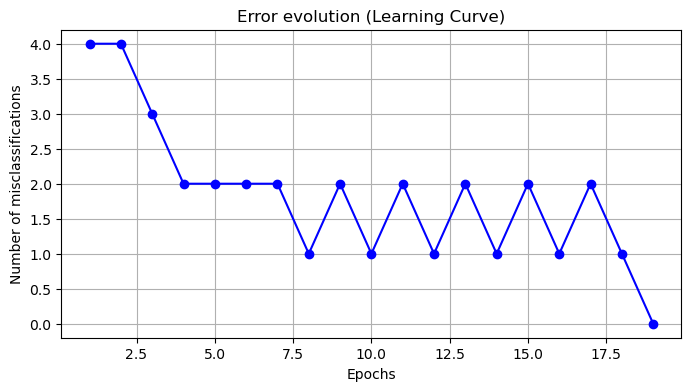

In [20]:
EPOCHS = 125
SEED = 4
LR = 0.0005
model = Perceptron(X.shape[1], lr=LR, seed=SEED)
errors = model.train(X,y_or,epochs = EPOCHS)
plot_learning_curve(errors,'Number of misclassifications')

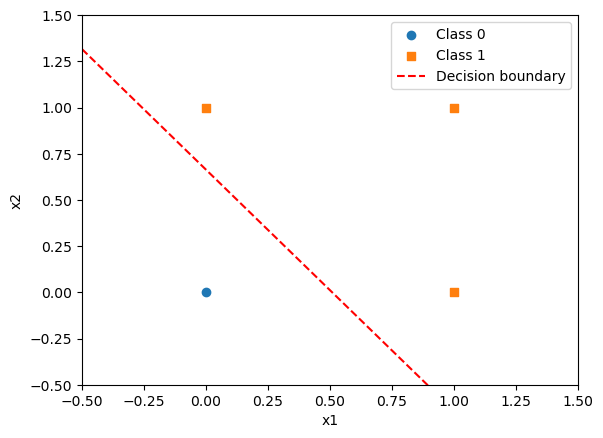

In [21]:

plot_decision_boundary(X, y_or, model)

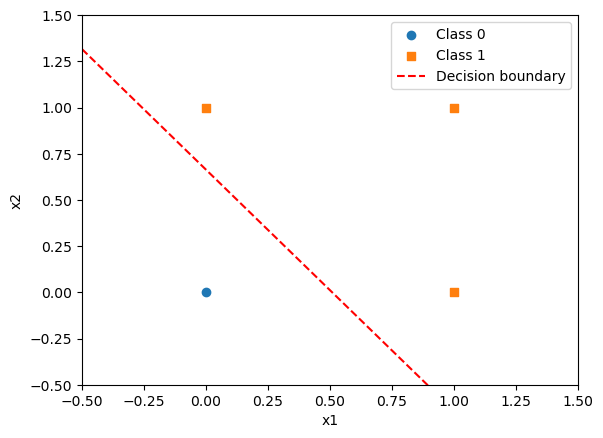

Weights: [0.00098209 0.00075283]
Epoch: 19 | Errores: 0


In [22]:
plot_training_animation(X,y_or,EPOCHS,SEED,LR)

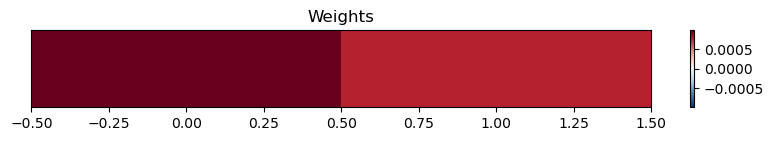

In [23]:
plot_neuron_heatmap(model)

In [24]:
print("Predictions:", model.predict(X))
print("Expected:   ", y_or)

Predictions: [0 1 1 1]
Expected:    [0. 1. 1. 1.]
